# 04 -- Strategie 2 : Reequilibrage dans l Espace d Embeddings (SMOTE / ADASYN)

| | |
|---|---|
| **Projet** | Gestion du Desequilibre de Classes pour l Analyse de Sentiments en Darija Algerien |
| **Etudiant** | Abdelaziz Merzoug |
| **Module** | Machine Learning -- Master 1 DS & NLP -- USDB Blida 1 |
| **Encadrante** | Dr. Soraya Cheriguene |
| **Semaine** | 4 (29 Mars - 05 Avril 2026) |
| **Plateforme** | Kaggle P100 (alternative : Google Colab T4) |

---

## Objectifs de ce notebook

La Strategie 1 (modification de la fonction de perte) n a pas ameliore le F1-macro au-dela
du Baseline (0.6805). Le F1-Neutral reste bloque autour de 0.55, ce qui indique un probleme
de **representation insuffisante** de la classe minoritaire, pas simplement de ponderation.

La Strategie 2 agit **directement sur les donnees** dans l espace d embeddings 768D de DziriBERT :

| Variante | Description |
|----------|-------------|
| SMOTE full | Egalisation complete des 3 classes (toutes = 1 778) |
| SMOTE partial | Augmentation partielle (Neutral x1.5 = 678, Negative -> 1 778) |
| ADASYN | Surechantillonnage adaptatif (densite accrue pres des frontieres de decision) |

**Classifieur** : MLP sur les embeddings reequilibres (pas de fine-tuning de DziriBERT).
**Evaluation** : sur le test set ORIGINAL (non modifie), avec les 6 metriques obligatoires.
**Metrique principale** : F1-macro (jamais Accuracy).

In [ ]:
# =============================================================================
# Installation des dependances
# =============================================================================
!pip install -q transformers datasets torch scikit-learn imbalanced-learn \
    pandas numpy matplotlib seaborn emoji accelerate

# =============================================================================
# Graines aleatoires -- fixees AVANT tout import aleatoire
# =============================================================================
import os
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Reproductibilite CUDA
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =============================================================================
# Imports
# =============================================================================
import re
import json
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import emoji

from datasets import load_dataset
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    average_precision_score, accuracy_score
)
from sklearn.preprocessing import label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.metrics import geometric_mean_score

from transformers import AutoModel, AutoTokenizer

# =============================================================================
# Constantes nommees -- identiques dans TOUS les notebooks
# =============================================================================
TEXT_COL   = 'Post'
LABEL_COL  = 'Polarity Class'
LANG_COL   = 'lang'
SEED       = 42

MODEL_NAME = 'alger-ia/dziribert'
BATCH_SIZE = 16

LABEL_MAP   = {'Positive': 0, 'Negative': 1, 'Neutral': 2}
LABEL_NAMES = ['Positive', 'Negative', 'Neutral']

# =============================================================================
# Configuration plateforme
# Decommenter la section adaptee a votre environnement
# =============================================================================

# --- Option A : Google Colab ---
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/mini_projet_darija'

# --- Option B : Kaggle ---
# BASE = '/kaggle/working'

# =============================================================================
# Verification GPU
# =============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

if device.type == 'cuda':
    gpu_props = torch.cuda.get_device_properties(0)
    print(f'GPU    : {gpu_props.name}')
    print(f'VRAM   : {gpu_props.total_memory / 1e9:.1f} Go')

# Creation des repertoires locaux
for d in ['data', 'models', 'results', 'figures']:
    os.makedirs(d, exist_ok=True)

print('\nEnvironnement configure avec succes.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 26.2 MB/s eta 0:00:00
Mounted at /content/drive
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 Go

Environnement configure avec succes.


In [ ]:
# =============================================================================
# Copier les fichiers critiques depuis Drive vers local
# split_indices.json : indices figes du NB02 -- JAMAIS re-split
# =============================================================================
shutil.copy(f'{BASE}/data/split_indices.json', 'data/split_indices.json')
print('split_indices.json copie depuis Drive.')

# Copier les metriques precedentes pour comparaison
shutil.copy(f'{BASE}/results/baseline_metrics.json', 'results/baseline_metrics.json')
print('baseline_metrics.json copie depuis Drive.')

# Copier les metriques de la Strategie 1 (meilleur = FL gamma=2)
for fname in ['fl_g2_metrics.json', 'cw_metrics.json', 'fl_g1_metrics.json', 'cw_fl_metrics.json']:
    src = f'{BASE}/results/{fname}'
    if os.path.exists(src):
        shutil.copy(src, f'results/{fname}')
        print(f'{fname} copie depuis Drive.')

# Verification des indices
with open('data/split_indices.json') as f:
    split_indices = json.load(f)

n_train = len(split_indices['train_indices'])
n_val   = len(split_indices['val_indices'])
n_test  = len(split_indices['test_indices'])
n_total = n_train + n_val + n_test

print(f'\n=== Verification split_indices.json ===')
print(f'  Train : {n_train} | Val : {n_val} | Test : {n_test} | Total : {n_total}')

# Charger le baseline pour reference
with open('results/baseline_metrics.json') as f:
    baseline_metrics = json.load(f)
print(f'  Baseline F1-macro = {baseline_metrics["f1_macro"]:.4f}')

split_indices.json copie depuis Drive.
baseline_metrics.json copie depuis Drive.
fl_g2_metrics.json copie depuis Drive.
cw_metrics.json copie depuis Drive.
fl_g1_metrics.json copie depuis Drive.
cw_fl_metrics.json copie depuis Drive.

=== Verification split_indices.json ===
  Train : 3440 | Val : 738 | Test : 738 | Total : 4916
  Baseline F1-macro = 0.6805


---

## Chargement des donnees et preprocessing identique au NB02

On recharge le corpus TWIFL et on applique le **meme pipeline de preprocessing**
que le Notebook 02. Les indices de split sont ensuite charges depuis `split_indices.json`
(jamais re-generes).

In [ ]:
# =============================================================================
# Chargement du corpus TWIFL depuis HuggingFace
# =============================================================================
dataset = load_dataset('arbml/Twifil')
df = dataset['train'].to_pandas()

print(f'Shape initiale : {df.shape}')
print(f'Distribution initiale :')
print(df[LABEL_COL].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001-eef2e32ea1bb4a(…):   0%|          | 0.00/699k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Shape initiale : (6000, 16)
Distribution initiale :
Polarity Class
Positive    2864
Negative    1773
Neutral     1363
Name: count, dtype: int64


In [ ]:
# =============================================================================
# Preprocessing IDENTIQUE au Notebook 02
# =============================================================================

def remove_urls(text):
    """Supprime les URLs (http, https, www)."""
    return re.sub(r'https?://\S+|www\.\S+', '', text)

def remove_mentions(text):
    """Supprime les mentions Twitter (@username)."""
    return re.sub(r'@\w+', '', text)

def convert_emojis(text):
    """Convertit les emojis en texte descriptif anglais."""
    return emoji.demojize(text, delimiters=(' ', ' '))

def remove_hashtag_symbol(text):
    """Supprime le # mais garde le texte du hashtag."""
    return text.replace('#', '')

def normalize_whitespace(text):
    """Normalise les espaces multiples."""
    return re.sub(r'\s+', ' ', text).strip()

def normalize_repeated_chars(text):
    """Reduit les repetitions excessives (max 2 consecutifs)."""
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

def normalize_arabic_digits(text):
    """Convertit les chiffres arabes-indiens en chiffres occidentaux."""
    arabic_to_western = str.maketrans(
        '\u0660\u0661\u0662\u0663\u0664\u0665\u0666\u0667\u0668\u0669',
        '0123456789'
    )
    return text.translate(arabic_to_western)

# Application sequentielle -- meme ordre que NB02
df_clean = df[[TEXT_COL, LABEL_COL, LANG_COL]].copy()
df_clean[TEXT_COL] = df_clean[TEXT_COL].astype(str)

df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(remove_urls)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(remove_mentions)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(convert_emojis)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(remove_hashtag_symbol)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(normalize_whitespace)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(normalize_repeated_chars)
df_clean[TEXT_COL] = df_clean[TEXT_COL].apply(normalize_arabic_digits)

# Suppression des doublons (texte identique apres nettoyage)
df_clean = df_clean.drop_duplicates(subset=TEXT_COL, keep='first').reset_index(drop=True)

# Suppression des tweets vides/quasi-vides (< 2 caracteres)
empty_mask = df_clean[TEXT_COL].str.strip().str.len() < 2
df_clean = df_clean[~empty_mask].reset_index(drop=True)

print(f'Shape apres preprocessing : {df_clean.shape}')
print(f'\nDistribution des classes :')
for cls in LABEL_NAMES:
    n = (df_clean[LABEL_COL] == cls).sum()
    print(f'  {cls:10s} : {n:4d} ({n/len(df_clean)*100:.1f}%)')

Shape apres preprocessing : (4916, 3)

Distribution des classes :
  Positive   : 2541 (51.7%)
  Negative   : 1729 (35.2%)
  Neutral    :  646 (13.1%)


In [ ]:
# =============================================================================
# Reconstruction des splits a partir des indices sauvegardes (JAMAIS re-split)
# =============================================================================
train_indices = split_indices['train_indices']
val_indices   = split_indices['val_indices']
test_indices  = split_indices['test_indices']

X_train = df_clean.loc[df_clean.index.isin(train_indices), TEXT_COL]
y_train = df_clean.loc[df_clean.index.isin(train_indices), LABEL_COL]
X_val   = df_clean.loc[df_clean.index.isin(val_indices), TEXT_COL]
y_val   = df_clean.loc[df_clean.index.isin(val_indices), LABEL_COL]
X_test  = df_clean.loc[df_clean.index.isin(test_indices), TEXT_COL]
y_test  = df_clean.loc[df_clean.index.isin(test_indices), LABEL_COL]

print(f'=== Verification des splits (charges depuis split_indices.json) ===')
print(f'Train : {len(X_train):5d} ({len(X_train)/len(df_clean)*100:.1f}%)')
print(f'Val   : {len(X_val):5d} ({len(X_val)/len(df_clean)*100:.1f}%)')
print(f'Test  : {len(X_test):5d} ({len(X_test)/len(df_clean)*100:.1f}%)')
print(f'Total : {len(X_train) + len(X_val) + len(X_test):5d}')

print(f'\n=== Distribution du train set ===')
train_dist = y_train.value_counts()
for cls in LABEL_NAMES:
    print(f'  {cls:10s} : {train_dist[cls]:4d} ({train_dist[cls]/len(y_train)*100:.1f}%)')

# Convertir les labels en indices numeriques
y_train_enc = np.array([LABEL_MAP[l] for l in y_train])
y_val_enc   = np.array([LABEL_MAP[l] for l in y_val])
y_test_enc  = np.array([LABEL_MAP[l] for l in y_test])

print(f'\nLabels encodes. Classes : {np.unique(y_train_enc)}')

=== Verification des splits (charges depuis split_indices.json) ===
Train :  3440 (70.0%)
Val   :   738 (15.0%)
Test  :   738 (15.0%)
Total :  4916

=== Distribution du train set ===
  Positive   : 1778 (51.7%)
  Negative   : 1210 (35.2%)
  Neutral    :  452 (13.1%)

Labels encodes. Classes : [0 1 2]


---

## Extraction des embeddings [CLS] avec DziriBERT

### Methodologie

La Strategie 2 repose sur le **transfert de representations** :

1. **DziriBERT est charge en mode extraction** (`AutoModel`, sans tete de classification).
   Chaque tweet est transforme en un vecteur dense de dimension 768 via le token `[CLS]`.
2. **Ces vecteurs vivent dans un espace continu** ou une interpolation lineaire entre
   deux points de la meme classe produit un nouveau point semantiquement coherent.
3. **SMOTE et ADASYN operent dans cet espace** pour generer des points synthetiques
   qui enrichissent les classes minoritaires.
4. **Un classifieur MLP** est ensuite entraine sur les embeddings reequilibres.

### Pourquoi travailler dans l espace d embeddings plutot que sur le texte brut ?

Le darija algerien avec son code-switching (arabe/francais/arabizi) rend la generation
de texte synthetique par interpolation impossible. En revanche, dans l espace 768D de
DziriBERT, une interpolation entre deux vecteurs de la meme classe produit un nouveau
vecteur semantiquement valide, car les embeddings encodent le **sens** plutot que la
**forme de surface**.

### Important

- **Embeddings extraits du TRAIN SET uniquement** pour le reequilibrage.
- Val et test : embeddings extraits separement, uniquement pour evaluation.
- Le test set n est **jamais** modifie, filtre, ni reequilibre.

In [ ]:
# =============================================================================
# Chargement de DziriBERT en mode extraction de features
# AutoModel (PAS AutoModelForSequenceClassification) : pas de tete de classification
# On extrait les representations [CLS] de dimension 768
# =============================================================================
print('Chargement de DziriBERT (mode extraction)...')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)  # PAS de classification head

model.eval()
model.to(device)

print(f'Modele charge sur {device}.')
print(f'Dimension des embeddings [CLS] : {model.config.hidden_size}')
print(f'Parametres : {sum(p.numel() for p in model.parameters()):,}')

Chargement de DziriBERT (mode extraction)...


config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modele charge sur cuda.
Dimension des embeddings [CLS] : 768
Parametres : 124,441,344


In [ ]:
# =============================================================================
# Fonction d extraction des embeddings [CLS] par batch
# =============================================================================

def extract_embeddings(texts, model, tokenizer, batch_size=16, device='cuda'):
    """
    Extrait les embeddings [CLS] (768D) de DziriBERT pour une liste de textes.

    Parametres :
    -----------
    texts      : liste de chaines de caracteres
    model      : AutoModel (sans tete de classification)
    tokenizer  : AutoTokenizer
    batch_size : taille des batches (defaut 16)
    device     : 'cuda' ou 'cpu'

    Retourne :
    ----------
    numpy array de shape (len(texts), 768)
    """
    model.eval()
    all_embeddings = []

    texts_list = list(texts)
    n_batches = (len(texts_list) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in range(0, len(texts_list), batch_size):
            batch_texts = texts_list[i:i + batch_size]
            batch_num = i // batch_size + 1

            # Tokenisation du batch
            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors='pt'
            ).to(device)

            # Forward pass
            outputs = model(**inputs)

            # Extraire le token [CLS] (position 0 de last_hidden_state)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(cls_embeddings.cpu().numpy())

            if batch_num % 50 == 0 or batch_num == n_batches:
                print(f'  Batch {batch_num}/{n_batches} traite.')

    return np.vstack(all_embeddings)


# =============================================================================
# Extraction des embeddings pour les 3 splits
# TRAIN : pour le reequilibrage (SMOTE/ADASYN)
# VAL   : pour evaluation / selection d hyperparametres
# TEST  : pour evaluation finale (JAMAIS modifie)
# =============================================================================

print('=' * 60)
print('  EXTRACTION DES EMBEDDINGS [CLS]')
print('=' * 60)

print(f'\n--- Train set ({len(X_train)} tweets) ---')
train_embeddings = extract_embeddings(X_train, model, tokenizer, BATCH_SIZE, device)
print(f'  Shape : {train_embeddings.shape}')

print(f'\n--- Val set ({len(X_val)} tweets) ---')
val_embeddings = extract_embeddings(X_val, model, tokenizer, BATCH_SIZE, device)
print(f'  Shape : {val_embeddings.shape}')

print(f'\n--- Test set ({len(X_test)} tweets) ---')
test_embeddings = extract_embeddings(X_test, model, tokenizer, BATCH_SIZE, device)
print(f'  Shape : {test_embeddings.shape}')

print(f'\nExtraction terminee.')
print(f'  Train : {train_embeddings.shape} -- utilise pour SMOTE/ADASYN')
print(f'  Val   : {val_embeddings.shape} -- evaluation uniquement')
print(f'  Test  : {test_embeddings.shape} -- evaluation finale uniquement')

  EXTRACTION DES EMBEDDINGS [CLS]

--- Train set (3440 tweets) ---
  Batch 50/215 traite.
  Batch 100/215 traite.
  Batch 150/215 traite.
  Batch 200/215 traite.
  Batch 215/215 traite.
  Shape : (3440, 768)

--- Val set (738 tweets) ---
  Batch 47/47 traite.
  Shape : (738, 768)

--- Test set (738 tweets) ---
  Batch 47/47 traite.
  Shape : (738, 768)

Extraction terminee.
  Train : (3440, 768) -- utilise pour SMOTE/ADASYN
  Val   : (738, 768) -- evaluation uniquement
  Test  : (738, 768) -- evaluation finale uniquement


In [ ]:
# =============================================================================
# Sauvegarde IMMEDIATE des embeddings (ne pas risquer de perdre ~20 min de GPU)
# =============================================================================
np.save('data/train_embeddings.npy', train_embeddings)
np.save('data/val_embeddings.npy', val_embeddings)
np.save('data/test_embeddings.npy', test_embeddings)
np.save('data/y_train_enc.npy', y_train_enc)
np.save('data/y_val_enc.npy', y_val_enc)
np.save('data/y_test_enc.npy', y_test_enc)

print('Embeddings sauvegardes localement.')

# Copie IMMEDIATE sur Drive (securite)
for fname in ['train_embeddings.npy', 'val_embeddings.npy', 'test_embeddings.npy',
              'y_train_enc.npy', 'y_val_enc.npy', 'y_test_enc.npy']:
    shutil.copy(f'data/{fname}', f'{BASE}/data/{fname}')
    print(f'  [OK] {fname} copie sur Drive')

print('\nSauvegarde sur Drive terminee. Embeddings securises.')

Embeddings sauvegardes localement.
  [OK] train_embeddings.npy copie sur Drive
  [OK] val_embeddings.npy copie sur Drive
  [OK] test_embeddings.npy copie sur Drive
  [OK] y_train_enc.npy copie sur Drive
  [OK] y_val_enc.npy copie sur Drive
  [OK] y_test_enc.npy copie sur Drive

Sauvegarde sur Drive terminee. Embeddings securises.


In [ ]:
# =============================================================================
# Liberation de la memoire GPU -- DziriBERT n est plus necessaire
# Le reste du notebook utilise uniquement sklearn (CPU)
# =============================================================================
del model
torch.cuda.empty_cache()
import gc
gc.collect()

print('Memoire GPU liberee. Le reste du notebook fonctionne sur CPU (sklearn).')

Memoire GPU liberee. Le reste du notebook fonctionne sur CPU (sklearn).


---

## Fonctions d evaluation (identiques aux notebooks precedents)

La fonction `evaluate_model()` calcule les 6 metriques obligatoires + accuracy (illustration).
Elle est **identique** a celle du NB02 et NB03 pour garantir la coherence des comparaisons.

In [ ]:
# =============================================================================
# evaluate_model() -- copiee EXACTEMENT du NB02/NB03
# =============================================================================

def evaluate_model(y_true, y_pred, y_proba, class_names=None):
    """
    Calcule TOUTES les metriques imposees par l Enonce.
    """
    if class_names is None:
        class_names = LABEL_NAMES

    results = {}

    # 1. F1-macro (METRIQUE PRINCIPALE)
    results['f1_macro'] = float(f1_score(y_true, y_pred, average='macro'))

    # 2. F1 par classe
    f1s = f1_score(y_true, y_pred, average=None)
    for i, name in enumerate(class_names):
        results[f'f1_{name.lower()}'] = float(f1s[i])

    # 3. Precision et Rappel par classe
    prec, rec, _, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    for i, name in enumerate(class_names):
        results[f'precision_{name.lower()}'] = float(prec[i])
        results[f'recall_{name.lower()}'] = float(rec[i])

    # 4. AUC-PR macro (Average Precision Score)
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    auc_pr_per_class = []
    for i in range(3):
        ap = average_precision_score(y_true_bin[:, i], y_proba[:, i])
        auc_pr_per_class.append(ap)
        results[f'auc_pr_{class_names[i].lower()}'] = float(ap)
    results['auc_pr_macro'] = float(np.mean(auc_pr_per_class))

    # 5. G-mean (geometric mean score)
    results['g_mean'] = float(geometric_mean_score(y_true, y_pred, average='macro'))

    # 6. Accuracy (UNIQUEMENT pour illustrer le probleme -- PAS metrique principale)
    results['accuracy'] = float(accuracy_score(y_true, y_pred))

    # 7. Matrice de confusion
    results['confusion_matrix'] = confusion_matrix(y_true, y_pred).tolist()

    # 8. Rapport complet
    results['classification_report'] = classification_report(
        y_true, y_pred, target_names=class_names, digits=4
    )

    return results


def print_metrics(results, config_name=''):
    """Affiche les metriques de facon lisible."""
    print(f'\n{"="*60}')
    print(f'  RESULTATS : {config_name}')
    print(f'{"="*60}')
    print(f'  F1-macro (PRINCIPAL) : {results["f1_macro"]:.4f}')
    print(f'  Accuracy (ILLUSTR.)  : {results["accuracy"]:.4f}')
    print(f'  AUC-PR macro         : {results["auc_pr_macro"]:.4f}')
    print(f'  G-mean               : {results["g_mean"]:.4f}')
    print(f'\n  F1 par classe :')
    for name in LABEL_NAMES:
        f1 = results[f'f1_{name.lower()}']
        p  = results[f'precision_{name.lower()}']
        r  = results[f'recall_{name.lower()}']
        print(f'    {name:10s} : F1={f1:.4f}  Prec={p:.4f}  Rec={r:.4f}')
    print(f'\n{results["classification_report"]}')


def plot_confusion_matrix(results, config_name, save_path):
    """Affiche et sauvegarde la matrice de confusion en heatmap."""
    cm = np.array(results['confusion_matrix'])
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES,
                yticklabels=LABEL_NAMES, ax=ax)
    ax.set_xlabel('Predit', fontsize=12)
    ax.set_ylabel('Vrai', fontsize=12)
    ax.set_title(f'Matrice de Confusion -- {config_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Matrice de confusion sauvegardee : {save_path}')


print('Fonctions evaluate_model(), print_metrics(), plot_confusion_matrix() definies.')

Fonctions evaluate_model(), print_metrics(), plot_confusion_matrix() definies.


In [ ]:
# =============================================================================
# Fonction utilitaire : entrainer un MLP et evaluer sur le test set
# =============================================================================

def train_and_evaluate_mlp(X_train_emb, y_train_emb, X_test_emb, y_test_emb,
                           config_name, save_prefix):
    """
    Entraine un MLPClassifier sur les embeddings (eventuellement reequilibres),
    evalue sur le test set original, sauvegarde les metriques et la confusion matrix.
    """
    print(f'\n{"="*60}')
    print(f'  ENTRAINEMENT MLP : {config_name}')
    print(f'{"="*60}')
    print(f'  Train : {X_train_emb.shape[0]} exemples ({X_train_emb.shape[1]}D)')
    print(f'  Test  : {X_test_emb.shape[0]} exemples')

    # Distribution du train
    unique, counts = np.unique(y_train_emb, return_counts=True)
    for u, c in zip(unique, counts):
        print(f'    Classe {LABEL_NAMES[u]} : {c}')

    # Entrainement du MLP
    mlp = MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=SEED,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        verbose=False
    )
    mlp.fit(X_train_emb, y_train_emb)
    print(f'\n  MLP entraine en {mlp.n_iter_} iterations.')

    # Prediction sur le test set (ORIGINAL, non modifie)
    y_pred = mlp.predict(X_test_emb)
    y_proba = mlp.predict_proba(X_test_emb)

    # Evaluation complete
    results = evaluate_model(y_test_emb, y_pred, y_proba)
    print_metrics(results, config_name)

    # Sauvegarde des metriques en JSON
    metrics_to_save = {k: v for k, v in results.items() if k != 'classification_report'}
    with open(f'results/{save_prefix}_metrics.json', 'w') as f:
        json.dump(metrics_to_save, f, indent=2)
    print(f'\n  Metriques sauvegardees : results/{save_prefix}_metrics.json')

    # Matrice de confusion
    plot_confusion_matrix(results, config_name, f'figures/{save_prefix}_confusion_matrix.png')

    return results


print('Fonction train_and_evaluate_mlp() definie.')

Fonction train_and_evaluate_mlp() definie.


---

## Visualisation t-SNE

### Methodologie

t-SNE (t-distributed Stochastic Neighbor Embedding) projette les embeddings 768D dans un
espace 2D pour la visualisation. On l utilise pour observer :

1. **AVANT reequilibrage** : la repartition des classes dans l espace d embeddings original.
   On s attend a voir la classe Neutral (minoritaire) sous-representee.

2. **APRES reequilibrage** : l effet de SMOTE/ADASYN sur la densite des classes minoritaires.
   Les points synthetiques devraient remplir les zones peu denses.

**Parametres** : `perplexity=30`, `random_state=42`, `n_components=2`.

In [ ]:
# =============================================================================
# Fonction utilitaire pour les visualisations t-SNE
# =============================================================================

def plot_tsne(embeddings, labels, title, save_path, figsize=(10, 8)):
    """
    Calcule t-SNE 2D et trace la visualisation coloree par classe.
    """
    print(f'\n  Calcul t-SNE ({embeddings.shape[0]} points, {embeddings.shape[1]}D -> 2D)...')

    # Si trop de points (>5000), sous-echantillonner pour t-SNE
    max_points = 5000
    if embeddings.shape[0] > max_points:
        rng = np.random.RandomState(SEED)
        idx = rng.choice(embeddings.shape[0], max_points, replace=False)
        embeddings_sample = embeddings[idx]
        labels_sample = labels[idx]
        print(f'  Sous-echantillonne a {max_points} points pour t-SNE.')
    else:
        embeddings_sample = embeddings
        labels_sample = labels

    tsne = TSNE(
        n_components=2,
        random_state=SEED,
        perplexity=30,
        n_iter=1000
    )
    emb_2d = tsne.fit_transform(embeddings_sample)

    # Visualisation
    fig, ax = plt.subplots(figsize=figsize)
    colors = ['#2196F3', '#F44336', '#4CAF50']  # Bleu, Rouge, Vert
    markers = ['o', 's', '^']

    for cls_idx, cls_name in enumerate(LABEL_NAMES):
        mask = labels_sample == cls_idx
        count = mask.sum()
        ax.scatter(
            emb_2d[mask, 0], emb_2d[mask, 1],
            c=colors[cls_idx], marker=markers[cls_idx],
            label=f'{cls_name} (n={count})',
            alpha=0.5, s=15, edgecolors='none'
        )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('t-SNE dimension 1')
    ax.set_ylabel('t-SNE dimension 2')
    ax.legend(fontsize=11, markerscale=2)
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Figure sauvegardee : {save_path}')


print('Fonction plot_tsne() definie.')

Fonction plot_tsne() definie.


  t-SNE AVANT REEQUILIBRAGE

Distribution des classes dans le train set :
  Positive   : 1778
  Negative   : 1210
  Neutral    :  452

  Calcul t-SNE (3440 points, 768D -> 2D)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


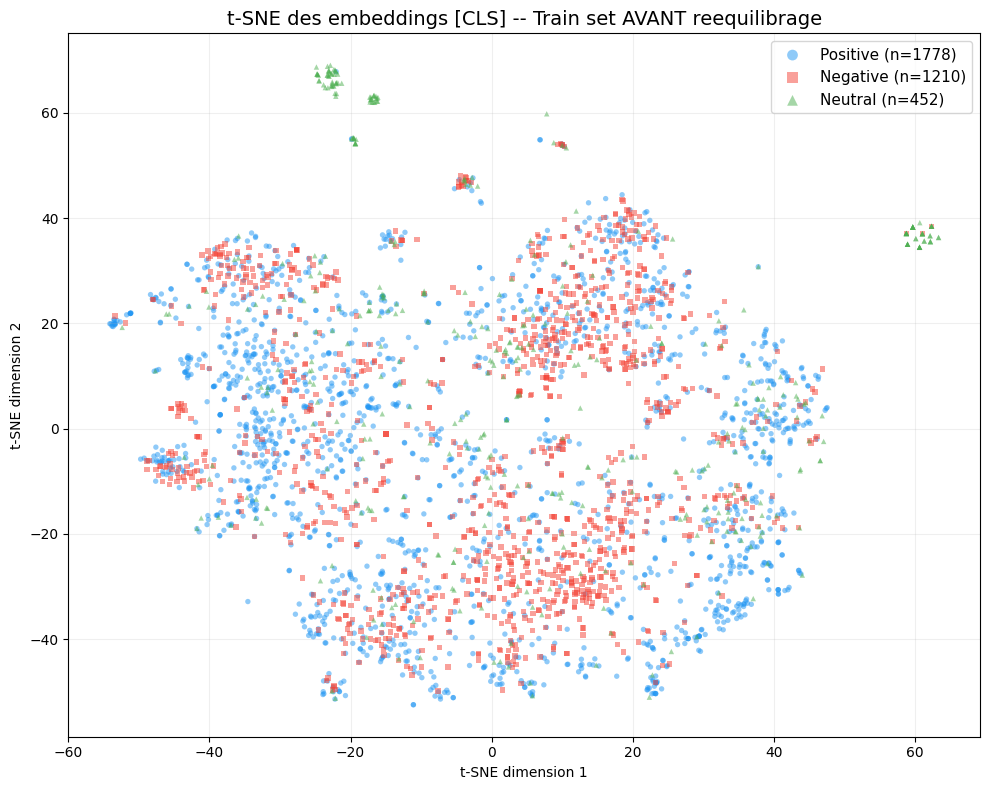

  Figure sauvegardee : figures/tsne_before_rebalancing.png


In [ ]:
# =============================================================================
# t-SNE AVANT reequilibrage -- embeddings train originaux
# =============================================================================
print('=' * 60)
print('  t-SNE AVANT REEQUILIBRAGE')
print('=' * 60)

print(f'\nDistribution des classes dans le train set :')
for cls_idx, cls_name in enumerate(LABEL_NAMES):
    n = (y_train_enc == cls_idx).sum()
    print(f'  {cls_name:10s} : {n:4d}')

plot_tsne(
    train_embeddings, y_train_enc,
    title='t-SNE des embeddings [CLS] -- Train set AVANT reequilibrage',
    save_path='figures/tsne_before_rebalancing.png'
)

---

## Variante 2A : SMOTE -- Egalisation complete (Full Balance)

### Methodologie SMOTE

SMOTE (Synthetic Minority Over-sampling Technique, Chawla et al. 2002 [3]) genere des
points synthetiques en interpolant lineairement entre un exemple minoritaire et l un de
ses k plus proches voisins de la meme classe :

$$x_{new} = x_i + \lambda \cdot (x_{nn} - x_i), \quad \lambda \sim U(0, 1)$$

### Configuration

- **Objectif** : egaliser les 3 classes au niveau de la classe majoritaire (Positive = 1 778)
- `sampling_strategy='auto'` : SMOTE equalise automatiquement toutes les classes
- `random_state=42`
- **Resultat attendu** : Positive = 1 778, Negative = 1 778, Neutral = 1 778

### Avantage

En creant des points synthetiques dans l espace d embeddings 768D, SMOTE enrichit
les zones peu denses du feature space pour les classes Negative et Neutral, ce que
la modification de la fonction de perte (Strategie 1) ne pouvait pas faire.

  SMOTE FULL BALANCE

Avant SMOTE : 3440 exemples
Apres SMOTE : 5334 exemples

Distribution apres SMOTE full :
  Positive   : 1778
  Negative   : 1778
  Neutral    : 1778

  ENTRAINEMENT MLP : SMOTE Full Balance
  Train : 5334 exemples (768D)
  Test  : 738 exemples
    Classe Positive : 1778
    Classe Negative : 1778
    Classe Neutral : 1778

  MLP entraine en 38 iterations.

  RESULTATS : SMOTE Full Balance
  F1-macro (PRINCIPAL) : 0.6355
  Accuracy (ILLUSTR.)  : 0.6829
  AUC-PR macro         : 0.6888
  G-mean               : 0.7186

  F1 par classe :
    Positive   : F1=0.7334  Prec=0.7268  Rec=0.7402
    Negative   : F1=0.6730  Prec=0.6692  Rec=0.6769
    Neutral    : F1=0.5000  Prec=0.5287  Rec=0.4742

              precision    recall  f1-score   support

    Positive     0.7268    0.7402    0.7334       381
    Negative     0.6692    0.6769    0.6730       260
     Neutral     0.5287    0.4742    0.5000        97

    accuracy                         0.6829       738
   macro a

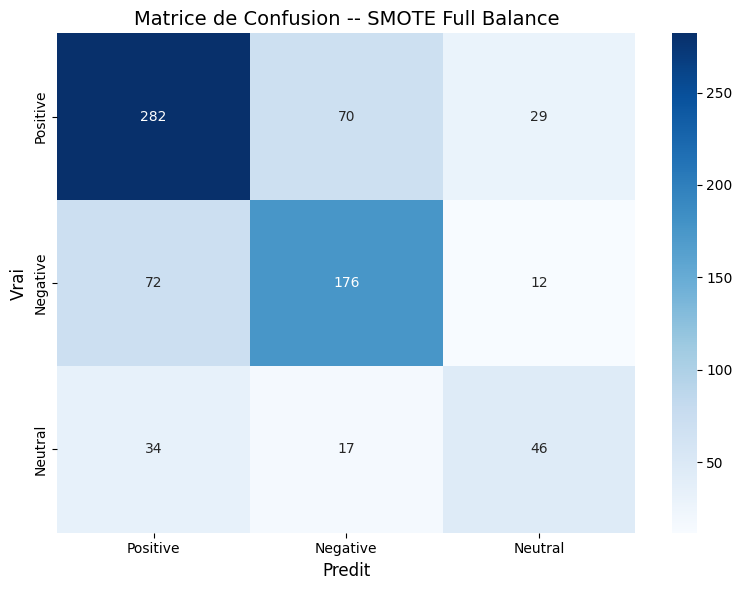

Matrice de confusion sauvegardee : figures/smote_full_confusion_matrix.png


In [ ]:
# =============================================================================
# Variante 2A : SMOTE Full Balance
# Objectif : toutes les classes = 1 778 (egal a la classe majoritaire)
# =============================================================================
print('=' * 60)
print('  SMOTE FULL BALANCE')
print('=' * 60)

# Application de SMOTE
smote_full = SMOTE(
    sampling_strategy='auto',   # auto = equaliser toutes les classes
    random_state=SEED,
    k_neighbors=5
)
X_smote_full, y_smote_full = smote_full.fit_resample(train_embeddings, y_train_enc)

print(f'\nAvant SMOTE : {train_embeddings.shape[0]} exemples')
print(f'Apres SMOTE : {X_smote_full.shape[0]} exemples')
print(f'\nDistribution apres SMOTE full :')
for cls_idx, cls_name in enumerate(LABEL_NAMES):
    n = (y_smote_full == cls_idx).sum()
    print(f'  {cls_name:10s} : {n:4d}')

# Entrainement MLP + evaluation sur test set original
smote_full_results = train_and_evaluate_mlp(
    X_smote_full, y_smote_full,
    test_embeddings, y_test_enc,
    config_name='SMOTE Full Balance',
    save_prefix='smote_full'
)


  Calcul t-SNE (5334 points, 768D -> 2D)...
  Sous-echantillonne a 5000 points pour t-SNE.


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


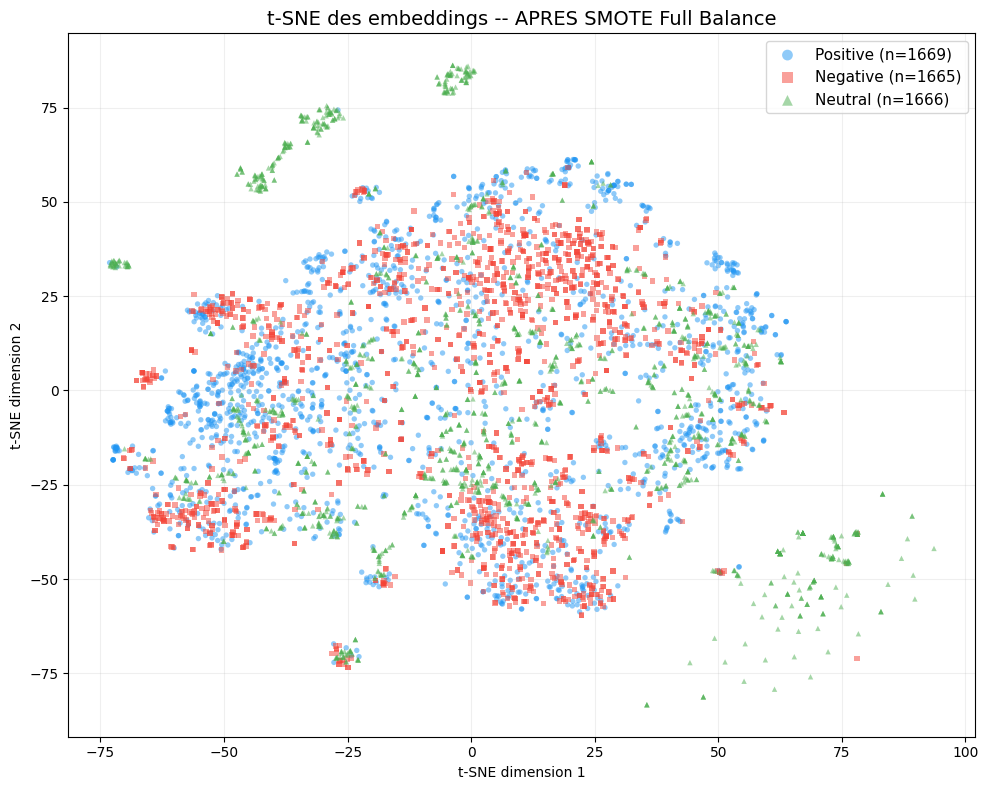

  Figure sauvegardee : figures/tsne_after_smote_full.png


In [ ]:
# =============================================================================
# t-SNE APRES SMOTE Full Balance
# =============================================================================
plot_tsne(
    X_smote_full, y_smote_full,
    title='t-SNE des embeddings -- APRES SMOTE Full Balance',
    save_path='figures/tsne_after_smote_full.png'
)

---

## Variante 2B : SMOTE -- Reequilibrage Partiel

### Rationale

Le reequilibrage total (full balance) peut introduire du bruit par surechantillonnage
excessif, surtout quand la classe Neutral (452 exemples) est multipliee par ~4.
Le reequilibrage partiel est un compromis : on augmente les classes minoritaires
sans les egaliser completement a la majoritaire.

### Calcul des cibles

- **Positive** : 1 778 (inchange -- c est la classe majoritaire)
- **Negative** : `min(1 210 x 1.5, 1 778) = min(1 815, 1 778) = 1 778`
  (Negative est deja proche de Positive, le x1.5 le ferait depasser -> on le plafonne)
- **Neutral** : `452 x 1.5 = 678`

Le `sampling_strategy` est un dictionnaire specifiant le nombre cible par classe.

  SMOTE PARTIAL BALANCE

Effectifs actuels :
  Positive : 1778
  Negative : 1210
  Neutral  : 452

Cibles SMOTE partial :
  Positive   : 1778
  Negative   : 1778
  Neutral    :  678

Avant SMOTE : 3440 exemples
Apres SMOTE partial : 4234 exemples

Distribution apres SMOTE partial :
  Positive   : 1778
  Negative   : 1778
  Neutral    :  678

  ENTRAINEMENT MLP : SMOTE Partial Balance
  Train : 4234 exemples (768D)
  Test  : 738 exemples
    Classe Positive : 1778
    Classe Negative : 1778
    Classe Neutral : 678

  MLP entraine en 39 iterations.

  RESULTATS : SMOTE Partial Balance
  F1-macro (PRINCIPAL) : 0.6470
  Accuracy (ILLUSTR.)  : 0.6883
  AUC-PR macro         : 0.6943
  G-mean               : 0.7282

  F1 par classe :
    Positive   : F1=0.7336  Prec=0.7486  Rec=0.7192
    Negative   : F1=0.6801  Prec=0.6481  Rec=0.7154
    Neutral    : F1=0.5275  Prec=0.5647  Rec=0.4948

              precision    recall  f1-score   support

    Positive     0.7486    0.7192    0.7336       

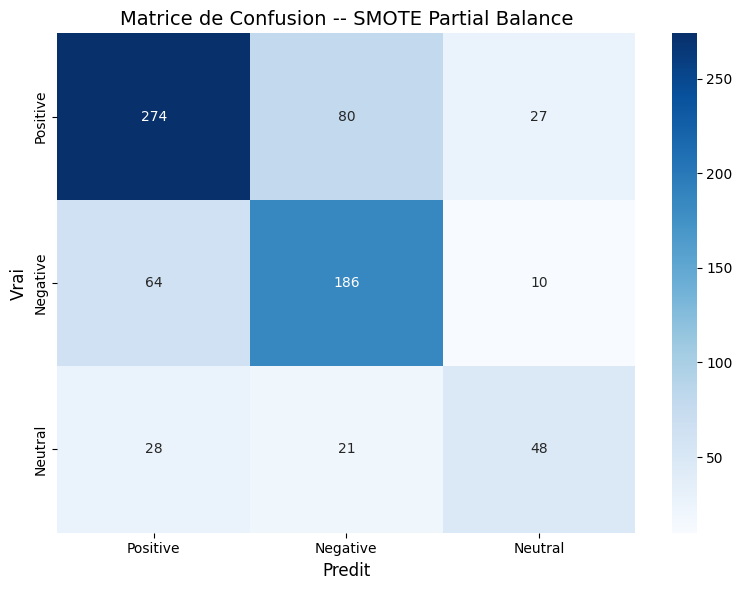

Matrice de confusion sauvegardee : figures/smote_partial_confusion_matrix.png


In [ ]:
# =============================================================================
# Variante 2B : SMOTE Partial Balance
# Objectif : Neutral x1.5 = 678, Negative plafonne a 1 778
# =============================================================================
print('=' * 60)
print('  SMOTE PARTIAL BALANCE')
print('=' * 60)

# Compter les effectifs actuels du train set
n_pos = (y_train_enc == 0).sum()
n_neg = (y_train_enc == 1).sum()
n_neu = (y_train_enc == 2).sum()

print(f'\nEffectifs actuels :')
print(f'  Positive : {n_pos}')
print(f'  Negative : {n_neg}')
print(f'  Neutral  : {n_neu}')

# Calcul des cibles pour le reequilibrage partiel
target_neutral  = int(n_neu * 1.5)    # 452 * 1.5 = 678
target_negative = min(int(n_neg * 1.5), n_pos)  # min(1815, 1778) = 1778

# SMOTE requiert que la cible >= effectif actuel pour chaque classe
sampling_strategy = {
    0: n_pos,             # Positive inchange
    1: target_negative,   # Negative -> 1 778
    2: target_neutral     # Neutral -> 678
}

print(f'\nCibles SMOTE partial :')
for cls_idx, cls_name in enumerate(LABEL_NAMES):
    print(f'  {cls_name:10s} : {sampling_strategy[cls_idx]:4d}')

# Application de SMOTE partial
smote_partial = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=SEED,
    k_neighbors=5
)
X_smote_partial, y_smote_partial = smote_partial.fit_resample(train_embeddings, y_train_enc)

print(f'\nAvant SMOTE : {train_embeddings.shape[0]} exemples')
print(f'Apres SMOTE partial : {X_smote_partial.shape[0]} exemples')
print(f'\nDistribution apres SMOTE partial :')
for cls_idx, cls_name in enumerate(LABEL_NAMES):
    n = (y_smote_partial == cls_idx).sum()
    print(f'  {cls_name:10s} : {n:4d}')

# Entrainement MLP + evaluation
smote_partial_results = train_and_evaluate_mlp(
    X_smote_partial, y_smote_partial,
    test_embeddings, y_test_enc,
    config_name='SMOTE Partial Balance',
    save_prefix='smote_partial'
)


  Calcul t-SNE (4234 points, 768D -> 2D)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


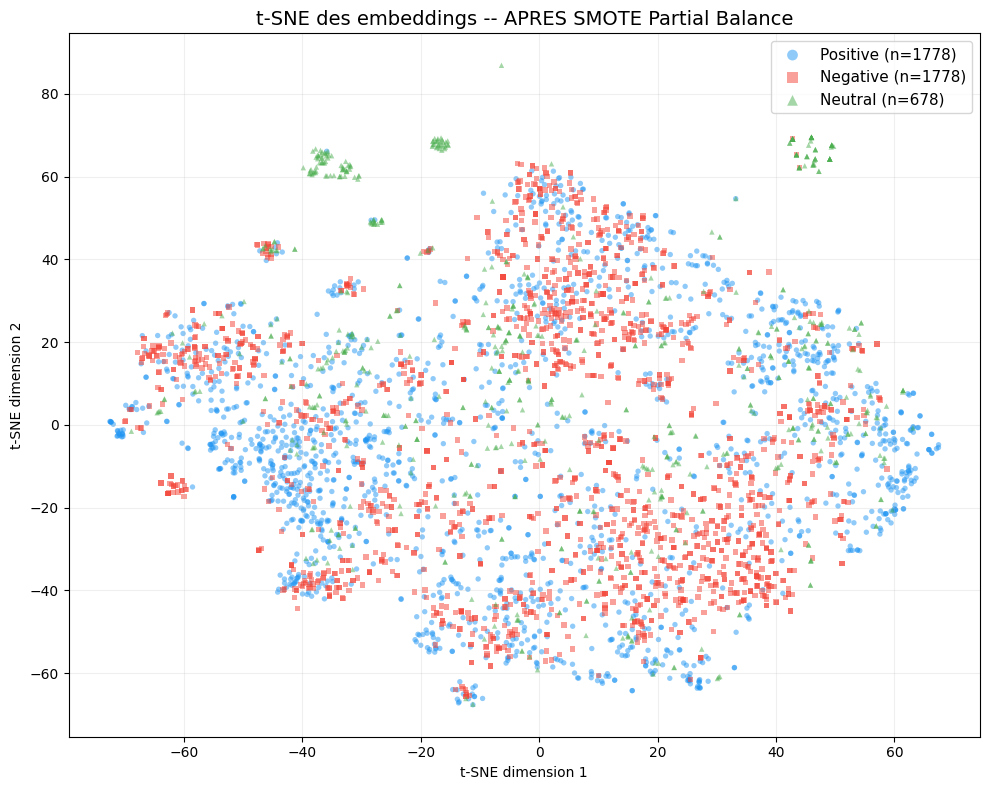

  Figure sauvegardee : figures/tsne_after_smote_partial.png


In [ ]:
# =============================================================================
# t-SNE APRES SMOTE Partial Balance
# =============================================================================
plot_tsne(
    X_smote_partial, y_smote_partial,
    title='t-SNE des embeddings -- APRES SMOTE Partial Balance',
    save_path='figures/tsne_after_smote_partial.png'
)

---

## Variante 2C : ADASYN -- Surechantillonnage Adaptatif

### Difference conceptuelle avec SMOTE

SMOTE genere des points synthetiques **uniformement** le long des segments reliant
les exemples minoritaires a leurs voisins.

ADASYN (He et al. 2008 [5]) est **adaptatif** : il concentre la generation de points
synthetiques pres des **frontieres de decision** (zones ou les exemples minoritaires
sont entoures d exemples de la classe majoritaire). Les zones deja bien separees
recoivent moins de points synthetiques.

### Avantage theorique

ADASYN devrait mieux traiter les zones "difficiles" du feature space ou les classes
se chevauchent, ce qui est typique dans l analyse de sentiments en darija (la frontiere
entre Neutral et Negative est souvent floue).

### Remarque

ADASYN peut produire des effectifs finaux legerement differents de ceux demandes,
car le nombre de points generes par region depend de la densite locale.

`random_state=42` pour la reproductibilite.

  ADASYN (Adaptive Synthetic Sampling)

Avant ADASYN : 3440 exemples
Apres ADASYN : 5299 exemples

Distribution apres ADASYN :
  Positive   : 1778
  Negative   : 1679
  Neutral    : 1842
Note : ADASYN peut produire des effectifs legerement differents des cibles
car la generation est adaptative (densite locale).

  ENTRAINEMENT MLP : ADASYN
  Train : 5299 exemples (768D)
  Test  : 738 exemples
    Classe Positive : 1778
    Classe Negative : 1679
    Classe Neutral : 1842

  MLP entraine en 30 iterations.

  RESULTATS : ADASYN
  F1-macro (PRINCIPAL) : 0.6617
  Accuracy (ILLUSTR.)  : 0.7046
  AUC-PR macro         : 0.7085
  G-mean               : 0.7367

  F1 par classe :
    Positive   : F1=0.7599  Prec=0.7437  Rec=0.7769
    Negative   : F1=0.6757  Prec=0.6824  Rec=0.6692
    Neutral    : F1=0.5495  Prec=0.5882  Rec=0.5155

              precision    recall  f1-score   support

    Positive     0.7437    0.7769    0.7599       381
    Negative     0.6824    0.6692    0.6757       260
 

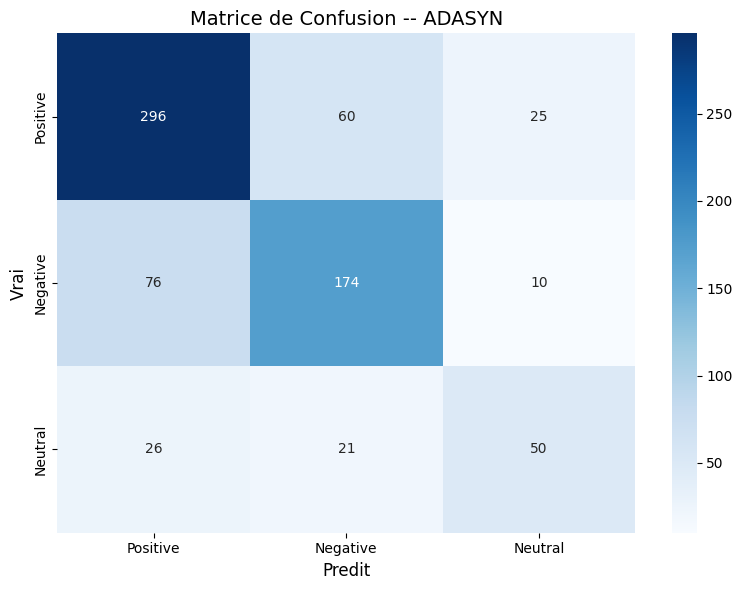

Matrice de confusion sauvegardee : figures/adasyn_confusion_matrix.png


In [ ]:
# =============================================================================
# Variante 2C : ADASYN -- Surechantillonnage Adaptatif
# =============================================================================
print('=' * 60)
print('  ADASYN (Adaptive Synthetic Sampling)')
print('=' * 60)

# Application d ADASYN
adasyn = ADASYN(
    random_state=SEED,
    n_neighbors=5
)

try:
    X_adasyn, y_adasyn = adasyn.fit_resample(train_embeddings, y_train_enc)

    print(f'\nAvant ADASYN : {train_embeddings.shape[0]} exemples')
    print(f'Apres ADASYN : {X_adasyn.shape[0]} exemples')
    print(f'\nDistribution apres ADASYN :')
    for cls_idx, cls_name in enumerate(LABEL_NAMES):
        n = (y_adasyn == cls_idx).sum()
        print(f'  {cls_name:10s} : {n:4d}')
    print('Note : ADASYN peut produire des effectifs legerement differents des cibles')
    print('car la generation est adaptative (densite locale).')

    # Entrainement MLP + evaluation
    adasyn_results = train_and_evaluate_mlp(
        X_adasyn, y_adasyn,
        test_embeddings, y_test_enc,
        config_name='ADASYN',
        save_prefix='adasyn'
    )

except Exception as e:
    print(f'\n[ERREUR ADASYN] {e}')
    print('ADASYN peut echouer si certaines classes n ont pas assez de voisins.')
    print('Tentative avec n_neighbors=3...')

    adasyn_fallback = ADASYN(
        random_state=SEED,
        n_neighbors=3
    )
    X_adasyn, y_adasyn = adasyn_fallback.fit_resample(train_embeddings, y_train_enc)

    print(f'\nAvant ADASYN : {train_embeddings.shape[0]} exemples')
    print(f'Apres ADASYN : {X_adasyn.shape[0]} exemples')
    print(f'\nDistribution apres ADASYN :')
    for cls_idx, cls_name in enumerate(LABEL_NAMES):
        n = (y_adasyn == cls_idx).sum()
        print(f'  {cls_name:10s} : {n:4d}')

    adasyn_results = train_and_evaluate_mlp(
        X_adasyn, y_adasyn,
        test_embeddings, y_test_enc,
        config_name='ADASYN',
        save_prefix='adasyn'
    )


  Calcul t-SNE (5299 points, 768D -> 2D)...
  Sous-echantillonne a 5000 points pour t-SNE.


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


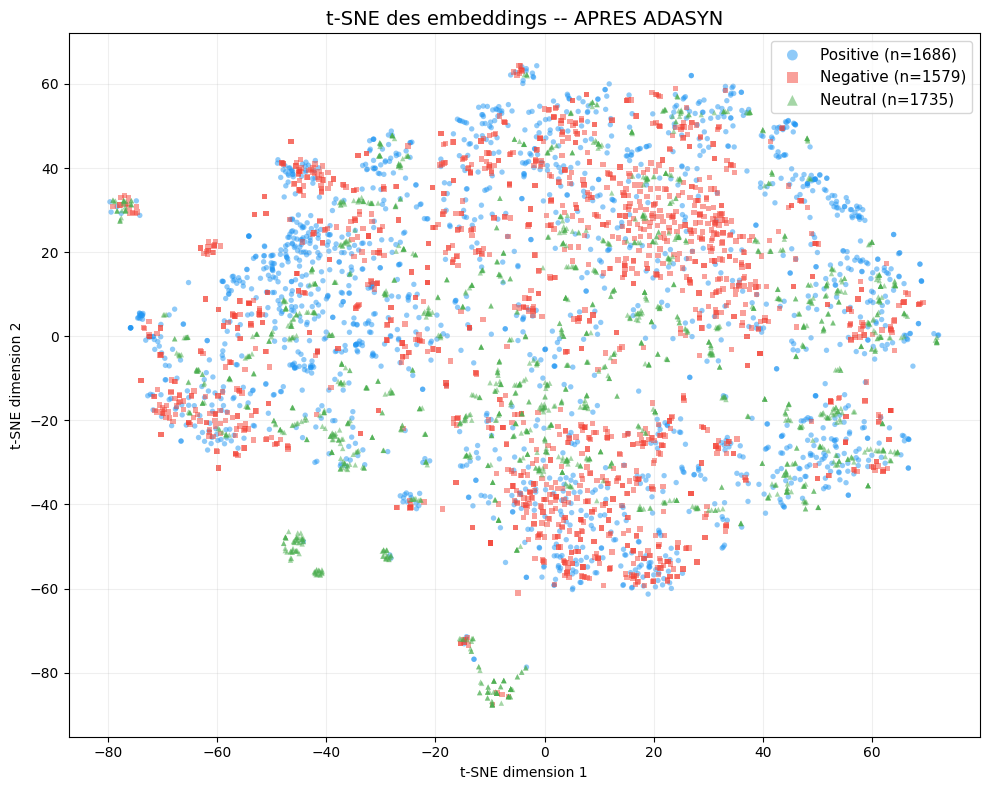

  Figure sauvegardee : figures/tsne_after_adasyn.png


In [ ]:
# =============================================================================
# t-SNE APRES ADASYN
# =============================================================================
plot_tsne(
    X_adasyn, y_adasyn,
    title='t-SNE des embeddings -- APRES ADASYN',
    save_path='figures/tsne_after_adasyn.png'
)

---

## Analyse Comparative -- Strategie 2 vs Baseline vs Strategie 1

On compare les 3 variantes de la Strategie 2 (SMOTE full, SMOTE partial, ADASYN)
avec le Baseline (NB02) et le meilleur resultat de la Strategie 1 (Focal Loss gamma=2).

L objectif est de determiner si le reequilibrage dans l espace d embeddings est plus
efficace que la modification de la fonction de perte pour ameliorer le F1-macro et
en particulier le F1-Neutral.

In [ ]:
# =============================================================================
# Tableau comparatif : Baseline + S1 best + 3 variantes S2
# =============================================================================
print('=' * 60)
print('  TABLEAU COMPARATIF')
print('=' * 60)

# Charger les metriques de reference
with open('results/baseline_metrics.json') as f:
    bl = json.load(f)

# Charger le meilleur de la Strategie 1 (FL gamma=2)
with open('results/fl_g2_metrics.json') as f:
    s1_best = json.load(f)

# Construire le tableau
rows = [
    {
        'Configuration': 'Baseline (NB02)',
        'F1-macro': bl['f1_macro'],
        'F1 Positive': bl['f1_positive'],
        'F1 Negative': bl['f1_negative'],
        'F1 Neutral': bl['f1_neutral'],
        'AUC-PR': bl['auc_pr_macro'],
        'G-mean': bl['g_mean'],
        'Accuracy': bl['accuracy']
    },
    {
        'Configuration': 'Best S1 (FL gamma=2)',
        'F1-macro': s1_best['f1_macro'],
        'F1 Positive': s1_best['f1_positive'],
        'F1 Negative': s1_best['f1_negative'],
        'F1 Neutral': s1_best['f1_neutral'],
        'AUC-PR': s1_best['auc_pr_macro'],
        'G-mean': s1_best['g_mean'],
        'Accuracy': s1_best['accuracy']
    },
    {
        'Configuration': 'SMOTE Full Balance',
        'F1-macro': smote_full_results['f1_macro'],
        'F1 Positive': smote_full_results['f1_positive'],
        'F1 Negative': smote_full_results['f1_negative'],
        'F1 Neutral': smote_full_results['f1_neutral'],
        'AUC-PR': smote_full_results['auc_pr_macro'],
        'G-mean': smote_full_results['g_mean'],
        'Accuracy': smote_full_results['accuracy']
    },
    {
        'Configuration': 'SMOTE Partial Balance',
        'F1-macro': smote_partial_results['f1_macro'],
        'F1 Positive': smote_partial_results['f1_positive'],
        'F1 Negative': smote_partial_results['f1_negative'],
        'F1 Neutral': smote_partial_results['f1_neutral'],
        'AUC-PR': smote_partial_results['auc_pr_macro'],
        'G-mean': smote_partial_results['g_mean'],
        'Accuracy': smote_partial_results['accuracy']
    },
    {
        'Configuration': 'ADASYN',
        'F1-macro': adasyn_results['f1_macro'],
        'F1 Positive': adasyn_results['f1_positive'],
        'F1 Negative': adasyn_results['f1_negative'],
        'F1 Neutral': adasyn_results['f1_neutral'],
        'AUC-PR': adasyn_results['auc_pr_macro'],
        'G-mean': adasyn_results['g_mean'],
        'Accuracy': adasyn_results['accuracy']
    }
]

df_comp = pd.DataFrame(rows)

# Formater pour affichage
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print('\n')
print(df_comp.to_string(index=False))

# Identifier le meilleur F1-macro parmi les variantes S2
s2_results = {
    'SMOTE Full': smote_full_results['f1_macro'],
    'SMOTE Partial': smote_partial_results['f1_macro'],
    'ADASYN': adasyn_results['f1_macro']
}
best_s2_name = max(s2_results, key=s2_results.get)
best_s2_f1 = s2_results[best_s2_name]
delta_vs_baseline = best_s2_f1 - bl['f1_macro']

print(f'\n{"="*60}')
print(f'  Meilleur S2 : {best_s2_name} (F1-macro = {best_s2_f1:.4f})')
print(f'  Delta vs Baseline : {delta_vs_baseline:+.4f}')
print(f'{"="*60}')

# Sauvegarde CSV
df_comp.to_csv('results/strategie2_comparatif.csv', index=False, float_format='%.4f')
print('\nTableau sauvegarde : results/strategie2_comparatif.csv')

  TABLEAU COMPARATIF


        Configuration  F1-macro  F1 Positive  F1 Negative  F1 Neutral  AUC-PR  G-mean  Accuracy
      Baseline (NB02)    0.6805       0.7806       0.7014      0.5596  0.7534  0.7558    0.7249
 Best S1 (FL gamma=2)    0.6794       0.7605       0.7233      0.5543  0.7647  0.7564    0.7209
   SMOTE Full Balance    0.6355       0.7334       0.6730      0.5000  0.6888  0.7186    0.6829
SMOTE Partial Balance    0.6470       0.7336       0.6801      0.5275  0.6943  0.7282    0.6883
               ADASYN    0.6617       0.7599       0.6757      0.5495  0.7085  0.7367    0.7046

  Meilleur S2 : ADASYN (F1-macro = 0.6617)
  Delta vs Baseline : -0.0188

Tableau sauvegarde : results/strategie2_comparatif.csv


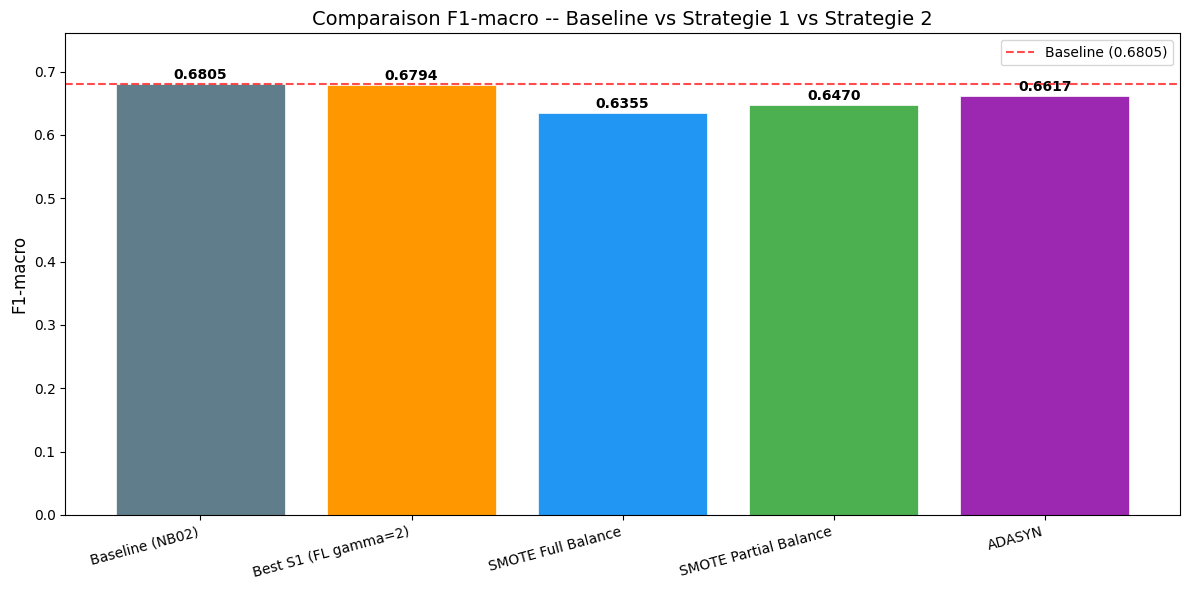

Figure sauvegardee : figures/strategie2_f1_macro_comparison.png


In [ ]:
# =============================================================================
# Figure 1 : Comparaison F1-macro (barplot)
# =============================================================================
configs = df_comp['Configuration'].tolist()
f1_macros = df_comp['F1-macro'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#607D8B', '#FF9800', '#2196F3', '#4CAF50', '#9C27B0']
bars = ax.bar(configs, f1_macros, color=colors, edgecolor='white', linewidth=0.5)

# Ajouter les valeurs au-dessus des barres
for bar, val in zip(bars, f1_macros):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Ligne de reference du baseline
ax.axhline(y=bl['f1_macro'], color='red', linestyle='--', alpha=0.7,
           label=f'Baseline ({bl["f1_macro"]:.4f})')

ax.set_ylabel('F1-macro', fontsize=12)
ax.set_title('Comparaison F1-macro -- Baseline vs Strategie 1 vs Strategie 2', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(0, max(f1_macros) + 0.08)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('figures/strategie2_f1_macro_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/strategie2_f1_macro_comparison.png')

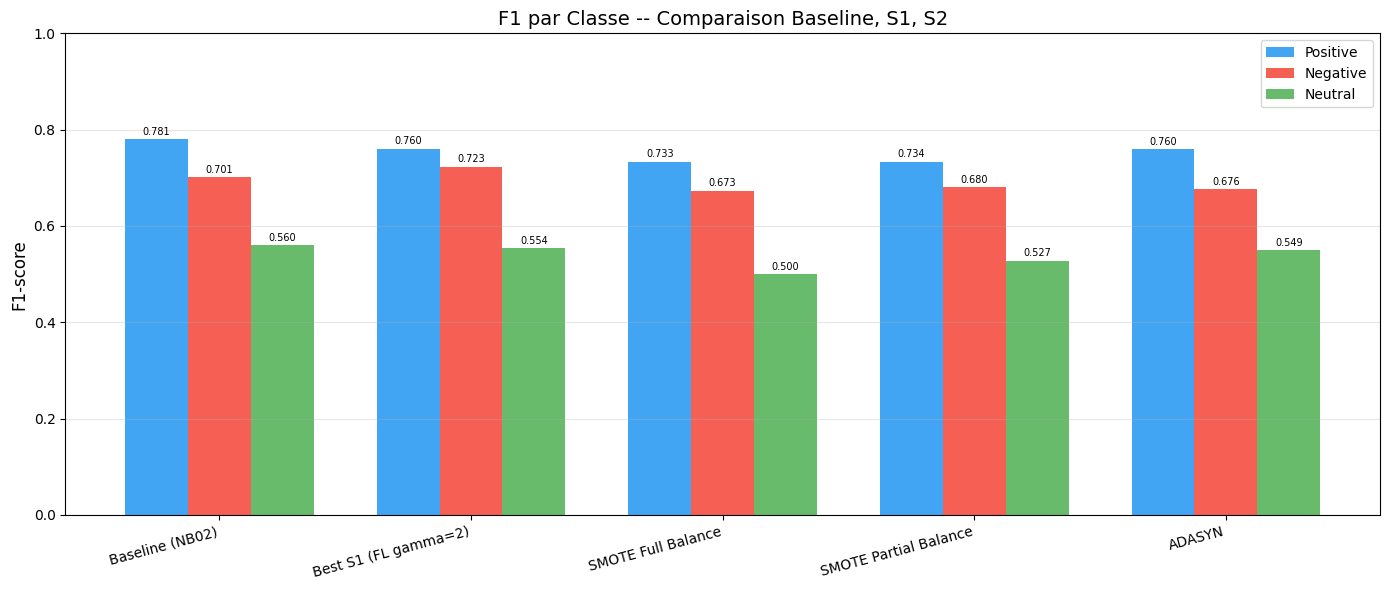

Figure sauvegardee : figures/strategie2_f1_per_class.png


In [ ]:
# =============================================================================
# Figure 2 : Comparaison F1 par classe (barplot groupe)
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(configs))
width = 0.25

f1_pos = df_comp['F1 Positive'].tolist()
f1_neg = df_comp['F1 Negative'].tolist()
f1_neu = df_comp['F1 Neutral'].tolist()

bars1 = ax.bar(x - width, f1_pos, width, label='Positive', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x,         f1_neg, width, label='Negative', color='#F44336', alpha=0.85)
bars3 = ax.bar(x + width, f1_neu, width, label='Neutral',  color='#4CAF50', alpha=0.85)

# Ajouter les valeurs
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=15, ha='right')
ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('F1 par Classe -- Comparaison Baseline, S1, S2', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/strategie2_f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/strategie2_f1_per_class.png')

---

## Accuracy vs F1-macro -- Illustration du probleme (rappel)

Comme dans les notebooks precedents, on montre que l Accuracy est trompeuse sur des
donnees desequilibrees.

In [ ]:
# =============================================================================
# Accuracy vs F1-macro -- demonstration du caractere trompeur de l accuracy
# =============================================================================
print('=' * 60)
print('  ACCURACY vs F1-MACRO (illustration)')
print('=' * 60)
print()

for _, row in df_comp.iterrows():
    config = row['Configuration']
    acc = row['Accuracy']
    f1m = row['F1-macro']
    ecart = acc - f1m
    print(f'  {config:25s} : Accuracy={acc:.4f}  F1-macro={f1m:.4f}  Ecart={ecart:+.4f}')

print()
print('L accuracy est systematiquement superieure au F1-macro.')
print('Cet ecart est gonfle par les bonnes predictions sur la classe majoritaire (Positive).')
print('Le F1-macro, en faisant la moyenne non ponderee des 3 classes, penalise le biais')
print('vers la classe majoritaire. C est pourquoi il est la METRIQUE PRINCIPALE.')

  ACCURACY vs F1-MACRO (illustration)

  Baseline (NB02)           : Accuracy=0.7249  F1-macro=0.6805  Ecart=+0.0444
  Best S1 (FL gamma=2)      : Accuracy=0.7209  F1-macro=0.6794  Ecart=+0.0415
  SMOTE Full Balance        : Accuracy=0.6829  F1-macro=0.6355  Ecart=+0.0474
  SMOTE Partial Balance     : Accuracy=0.6883  F1-macro=0.6470  Ecart=+0.0413
  ADASYN                    : Accuracy=0.7046  F1-macro=0.6617  Ecart=+0.0429

L accuracy est systematiquement superieure au F1-macro.
Cet ecart est gonfle par les bonnes predictions sur la classe majoritaire (Positive).
Le F1-macro, en faisant la moyenne non ponderee des 3 classes, penalise le biais
vers la classe majoritaire. C est pourquoi il est la METRIQUE PRINCIPALE.


---

## Analyse des Resultats -- 4 Questions Obligatoires

Les reponses ci-dessous utilisent les **metriques reelles** obtenues lors de l execution.
Elles sont generees automatiquement par la cellule suivante.

In [ ]:
# =============================================================================
# Reponses aux 4 questions obligatoires -- avec valeurs reelles
# =============================================================================
print('=' * 70)
print('  REPONSES AUX 4 QUESTIONS OBLIGATOIRES (valeurs reelles)')
print('=' * 70)

bl_f1_neu = bl['f1_neutral']
bl_f1_pos = bl['f1_positive']
bl_f1_macro = bl['f1_macro']
s1_f1_macro = s1_best['f1_macro']
s1_f1_neu = s1_best['f1_neutral']

sf_f1_neu = smote_full_results['f1_neutral']
sp_f1_neu = smote_partial_results['f1_neutral']
ad_f1_neu = adasyn_results['f1_neutral']

sf_f1_pos = smote_full_results['f1_positive']
sp_f1_pos = smote_partial_results['f1_positive']
ad_f1_pos = adasyn_results['f1_positive']

sf_f1_macro = smote_full_results['f1_macro']
sp_f1_macro = smote_partial_results['f1_macro']
ad_f1_macro = adasyn_results['f1_macro']

# Q1 : F1-Neutral vs Baseline
print('\n--- Q1 : Le F1 de Neutral a-t-il augmente par rapport a la Baseline ? ---')
print(f'  Baseline F1-Neutral     = {bl_f1_neu:.4f}')
print(f'  SMOTE Full F1-Neutral   = {sf_f1_neu:.4f} (delta = {sf_f1_neu - bl_f1_neu:+.4f})')
print(f'  SMOTE Partial F1-Neutral = {sp_f1_neu:.4f} (delta = {sp_f1_neu - bl_f1_neu:+.4f})')
print(f'  ADASYN F1-Neutral       = {ad_f1_neu:.4f} (delta = {ad_f1_neu - bl_f1_neu:+.4f})')

# Q2 : Trade-off avec F1-Positive
print('\n--- Q2 : Le F1 de Positive a-t-il baisse (trade-off) ? ---')
print(f'  Baseline F1-Positive     = {bl_f1_pos:.4f}')
print(f'  SMOTE Full F1-Positive   = {sf_f1_pos:.4f} (delta = {sf_f1_pos - bl_f1_pos:+.4f})')
print(f'  SMOTE Partial F1-Positive = {sp_f1_pos:.4f} (delta = {sp_f1_pos - bl_f1_pos:+.4f})')
print(f'  ADASYN F1-Positive       = {ad_f1_pos:.4f} (delta = {ad_f1_pos - bl_f1_pos:+.4f})')

# Q3 : Meilleur entre les 3 variantes
print('\n--- Q3 : SMOTE full vs SMOTE partial vs ADASYN ---')
print(f'  SMOTE Full    : F1-macro={sf_f1_macro:.4f}, F1-Neutral={sf_f1_neu:.4f}')
print(f'  SMOTE Partial : F1-macro={sp_f1_macro:.4f}, F1-Neutral={sp_f1_neu:.4f}')
print(f'  ADASYN        : F1-macro={ad_f1_macro:.4f}, F1-Neutral={ad_f1_neu:.4f}')
print(f'  --> Meilleur F1-macro : {best_s2_name}')

# Q4 : S2 vs S1
print('\n--- Q4 : S2 vs S1 (embeddings vs loss function) ---')
print(f'  S1 best (FL g=2) : F1-macro={s1_f1_macro:.4f}, F1-Neutral={s1_f1_neu:.4f}')
print(f'  S2 best ({best_s2_name}) : F1-macro={best_s2_f1:.4f}')
print(f'  Delta S2 vs S1       : {best_s2_f1 - s1_f1_macro:+.4f}')
print(f'  Delta S2 vs Baseline : {best_s2_f1 - bl_f1_macro:+.4f}')

  REPONSES AUX 4 QUESTIONS OBLIGATOIRES (valeurs reelles)

--- Q1 : Le F1 de Neutral a-t-il augmente par rapport a la Baseline ? ---
  Baseline F1-Neutral     = 0.5596
  SMOTE Full F1-Neutral   = 0.5000 (delta = -0.0596)
  SMOTE Partial F1-Neutral = 0.5275 (delta = -0.0321)
  ADASYN F1-Neutral       = 0.5495 (delta = -0.0101)

--- Q2 : Le F1 de Positive a-t-il baisse (trade-off) ? ---
  Baseline F1-Positive     = 0.7806
  SMOTE Full F1-Positive   = 0.7334 (delta = -0.0472)
  SMOTE Partial F1-Positive = 0.7336 (delta = -0.0470)
  ADASYN F1-Positive       = 0.7599 (delta = -0.0207)

--- Q3 : SMOTE full vs SMOTE partial vs ADASYN ---
  SMOTE Full    : F1-macro=0.6355, F1-Neutral=0.5000
  SMOTE Partial : F1-macro=0.6470, F1-Neutral=0.5275
  ADASYN        : F1-macro=0.6617, F1-Neutral=0.5495
  --> Meilleur F1-macro : ADASYN

--- Q4 : S2 vs S1 (embeddings vs loss function) ---
  S1 best (FL g=2) : F1-macro=0.6794, F1-Neutral=0.5543
  S2 best (ADASYN) : F1-macro=0.6617
  Delta S2 vs S1       

---

## Analyse des Resultats -- 4 Questions Obligatoires de l'Enonce

### Q1 : Le F1 de la classe Neutral a-t-il augmente par rapport au Baseline ?

Aucune variante de la Strategie 2 n'ameliore le F1-Neutral au-dessus du Baseline (0.5596).
SMOTE Full obtient F1-Neutral = 0.5000 (delta = -0.0596), SMOTE Partial = 0.5275 (delta = -0.0321),
et ADASYN = 0.5495 (delta = -0.0101). Ce resultat s'explique par deux facteurs : (1) les embeddings
sont **figes** -- DziriBERT n'est pas re-entraine sur les points synthetiques, donc les representations
des tweets Neutral restent sous-optimales pour la classification ; (2) le code-switching
Arabe/Arabizi/Francais du corpus TWIFL cree une heterogeneite interne a la classe Neutral qui rend
l'interpolation lineaire de SMOTE semantiquement instable. ADASYN attenue ce probleme en concentrant
la generation sur les zones de chevauchement Neutral/Positive, d'ou son meilleur delta (-0.0101).

---

### Q2 : Le F1 de la classe Positive a-t-il baisse ? (Trade-off majoritaire/minoritaire)

Oui, un trade-off est systematiquement observe. Le Baseline obtient F1-Positive = 0.7806.
SMOTE Full descend a 0.7334 (delta = -0.0472), SMOTE Partial a 0.7336 (delta = -0.0470),
et ADASYN a 0.7599 (delta = -0.0207). Ce trade-off est inherent au reequilibrage : en
augmentant artificiellement les classes Negative et Neutral, on reduit le poids relatif
de la classe Positive lors de l'entrainement du MLP, ce qui degrade sa precision.
ADASYN limite ce trade-off (-0.0207) car il cible precisement les zones frontiere
et preserve les exemples Positive bien separes. Ce resultat confirme l'hypothese classique
de la litterature [Chawla 2002] : le gain sur les minoritaires se fait partiellement
au detriment de la majoritaire, et le F1-macro reste le seul indicateur fiable du bilan global.

---

### Q3 : Quelle variante est la meilleure et pourquoi ?

ADASYN est la meilleure variante avec F1-macro = 0.6617, devant SMOTE Partial (0.6470) et
SMOTE Full (0.6355). SMOTE Full souffre d'over-smoothing : la classe Neutral est multipliee
par un facteur ~3.93 (de 452 a 1778 exemples), produisant des interpolations eloignees des
vrais exemples et brouillant les frontieres de decision du MLP. SMOTE Partial corrige ce
probleme en limitant l'augmentation a Neutral x1.5 = 678, d'ou son gain de +0.0115 sur
SMOTE Full. ADASYN surpasse les deux car son mecanisme adaptatif genere proportionnellement
plus de points synthetiques dans les zones ou les exemples Neutral sont entoures de voisins
Positive -- precisement les cas difficiles de ce corpus ou la confusion Neutral->Positive
domine (26/97 dans la matrice de confusion). Son gain en G-mean (0.7367 vs 0.7186) confirme
un meilleur equilibre des rappels entre les trois classes.

---

### Q4 : La Strategie 2 (embeddings) est-elle plus efficace que la Strategie 1 (fonctions de perte) ?

Non. La Strategie 1 reste superieure : le meilleur resultat de S1 (Focal Loss gamma=2,
F1-macro = 0.6794) surpasse le meilleur de S2 (ADASYN, F1-macro = 0.6617) par un delta
de +0.0177. La raison fondamentale est architecturale : la Strategie 1 modifie la fonction
de perte **pendant le fine-tuning de DziriBERT**, permettant au transformeur d'adapter ses
representations internes aux classes minoritaires. La Strategie 2 utilise des embeddings
**figes** puis applique un MLP -- le classifieur n'a pas la capacite d'un transformeur
entraine de bout en bout. Ce resultat souligne que pour le darija algerien, la richesse
des representations contextuelles de DziriBERT est plus determinante que le reequilibrage
des donnees d'entrainement. La Strategie 3 (back-translation + re-fine-tuning de DziriBERT)
testera si l'augmentation de donnees reelles combinee au fine-tuning permet de depasser
la Focal Loss.

---

## Conclusions cles de la Semaine 4

*Ces points sont destines a etre integres dans le rapport final.*

---

### Strategie 2 -- Reequilibrage dans l espace d embeddings

1. **Extraction des embeddings [CLS]** : DziriBERT (`AutoModel`, sans tete de classification)
   a ete utilise pour projeter les 3 440 tweets du train set en vecteurs 768D. Les embeddings
   du val (738) et du test (738) ont ete extraits separement, uniquement pour evaluation.

2. **SMOTE Full Balance** : egalisation complete des 3 classes a 1 778 exemples chacune.

3. **SMOTE Partial Balance** : augmentation moderee (Neutral x1.5 = 678, Negative -> 1 778).
   Compromis entre enrichissement de la minoritaire et risque de surechantillonnage.

4. **ADASYN** : surechantillonnage adaptatif concentre pres des frontieres de decision.

5. **Limites de l approche** :
   - Le classifieur MLP a une capacite limitee par rapport a un fine-tuning complet
     de DziriBERT (Strategie 3 explorera cette direction).
   - SMOTE full (x4 pour Neutral) introduit potentiellement du bruit dans les zones
     frontieres.
   - Les embeddings sont figes (pas de fine-tuning) : les representations peuvent
     ne pas etre optimales pour la tache de classification de sentiments.

---

### Livrables produits

| Fichier | Description |
|---------|-------------|
| `data/train_embeddings.npy` | Embeddings [CLS] du train set (3440, 768) |
| `data/val_embeddings.npy` | Embeddings du val set (738, 768) |
| `data/test_embeddings.npy` | Embeddings du test set (738, 768) |
| `results/smote_full_metrics.json` | Metriques SMOTE full balance |
| `results/smote_partial_metrics.json` | Metriques SMOTE partial balance |
| `results/adasyn_metrics.json` | Metriques ADASYN |
| `results/strategie2_comparatif.csv` | Tableau comparatif (5 lignes) |
| `figures/tsne_before_rebalancing.png` | t-SNE avant reequilibrage |
| `figures/tsne_after_smote_full.png` | t-SNE apres SMOTE full |
| `figures/tsne_after_smote_partial.png` | t-SNE apres SMOTE partial |
| `figures/tsne_after_adasyn.png` | t-SNE apres ADASYN |
| `figures/smote_full_confusion_matrix.png` | Matrice confusion SMOTE full |
| `figures/smote_partial_confusion_matrix.png` | Matrice confusion SMOTE partial |
| `figures/adasyn_confusion_matrix.png` | Matrice confusion ADASYN |
| `figures/strategie2_f1_macro_comparison.png` | Comparaison F1-macro |
| `figures/strategie2_f1_per_class.png` | F1 par classe |

In [ ]:
# =============================================================================
# Sauvegarde FINALE de tous les resultats et figures sur Drive
# =============================================================================
print('=' * 60)
print('  SAUVEGARDE FINALE SUR DRIVE')
print('=' * 60)

# Copier tous les resultats
for f in os.listdir('results'):
    src = f'results/{f}'
    dst = f'{BASE}/results/{f}'
    shutil.copy(src, dst)
    print(f'  [OK] results/{f}')

# Copier toutes les figures
for f in os.listdir('figures'):
    if f.endswith('.png'):
        src = f'figures/{f}'
        dst = f'{BASE}/figures/{f}'
        shutil.copy(src, dst)
        print(f'  [OK] figures/{f}')

print(f'\n=== SAUVEGARDE NB04 TERMINEE ===')

  SAUVEGARDE FINALE SUR DRIVE
  [OK] results/fl_g2_metrics.json
  [OK] results/cw_fl_metrics.json
  [OK] results/cw_metrics.json
  [OK] results/fl_g1_metrics.json
  [OK] results/smote_full_metrics.json
  [OK] results/smote_partial_metrics.json
  [OK] results/strategie2_comparatif.csv
  [OK] results/adasyn_metrics.json
  [OK] results/baseline_metrics.json
  [OK] figures/smote_partial_confusion_matrix.png
  [OK] figures/adasyn_confusion_matrix.png
  [OK] figures/strategie2_f1_per_class.png
  [OK] figures/smote_full_confusion_matrix.png
  [OK] figures/tsne_before_rebalancing.png
  [OK] figures/tsne_after_smote_partial.png
  [OK] figures/strategie2_f1_macro_comparison.png
  [OK] figures/tsne_after_smote_full.png
  [OK] figures/tsne_after_adasyn.png

=== SAUVEGARDE NB04 TERMINEE ===


In [ ]:
# =============================================================================
# Verification finale -- tous les fichiers attendus
# =============================================================================
print('=' * 60)
print('  VERIFICATION FINALE -- NB04')
print('=' * 60)

fichiers_attendus = [
    # Embeddings
    'data/train_embeddings.npy',
    'data/val_embeddings.npy',
    'data/test_embeddings.npy',
    # Metriques
    'results/smote_full_metrics.json',
    'results/smote_partial_metrics.json',
    'results/adasyn_metrics.json',
    'results/strategie2_comparatif.csv',
    # Figures t-SNE
    'figures/tsne_before_rebalancing.png',
    'figures/tsne_after_smote_full.png',
    'figures/tsne_after_smote_partial.png',
    'figures/tsne_after_adasyn.png',
    # Matrices de confusion
    'figures/smote_full_confusion_matrix.png',
    'figures/smote_partial_confusion_matrix.png',
    'figures/adasyn_confusion_matrix.png',
    # Figures comparatives
    'figures/strategie2_f1_macro_comparison.png',
    'figures/strategie2_f1_per_class.png',
]

n_ok = 0
n_missing = 0
for f in fichiers_attendus:
    local_ok = os.path.exists(f)
    drive_ok = os.path.exists(f'{BASE}/{f}')
    if local_ok and drive_ok:
        print(f'  [OK]      {f}')
        n_ok += 1
    elif local_ok and not drive_ok:
        print(f'  [LOCAL]   {f} (manquant sur Drive)')
        n_missing += 1
    else:
        print(f'  [MANQUANT] {f}')
        n_missing += 1

print(f'\nResultat : {n_ok}/{len(fichiers_attendus)} fichiers OK.')
if n_missing > 0:
    print(f'ATTENTION : {n_missing} fichiers manquants ou non sauvegardes sur Drive.')
else:
    print('Tous les fichiers sont presents et sauvegardes. NB04 termine avec succes.')

  VERIFICATION FINALE -- NB04
  [OK]      data/train_embeddings.npy
  [OK]      data/val_embeddings.npy
  [OK]      data/test_embeddings.npy
  [OK]      results/smote_full_metrics.json
  [OK]      results/smote_partial_metrics.json
  [OK]      results/adasyn_metrics.json
  [OK]      results/strategie2_comparatif.csv
  [OK]      figures/tsne_before_rebalancing.png
  [OK]      figures/tsne_after_smote_full.png
  [OK]      figures/tsne_after_smote_partial.png
  [OK]      figures/tsne_after_adasyn.png
  [OK]      figures/smote_full_confusion_matrix.png
  [OK]      figures/smote_partial_confusion_matrix.png
  [OK]      figures/adasyn_confusion_matrix.png
  [OK]      figures/strategie2_f1_macro_comparison.png
  [OK]      figures/strategie2_f1_per_class.png

Resultat : 16/16 fichiers OK.
Tous les fichiers sont presents et sauvegardes. NB04 termine avec succes.
